In [7]:
import sys
sys.path.insert(0, '..')

import numpy as np
from core.activations import Activations

act = Activations()

x = np.array([-1.0, 0.5, 2.0, -0.3, 1.1])
T = 0.5

print(f"x       = {x}")
print(f"max(x)  = {np.max(x)}")
print(f"min(x)  = {np.min(x)}")
print()
print(f"LogSumExp(T=0)   = {act.LogSumExp(x, temp=0.0)}")
print(f"LogSumExp(T={T})  = {act.LogSumExp(x, temp=T)}")
print()
print(f"SmoothMin(T=0)   = {act.SmoothMin(x, temp=0.0)}")
print(f"SmoothMin(T={T})  = {act.SmoothMin(x, temp=T)}")
print()
print(f"Relu (Softplus(T=0))             = {act.Relu(x)}")
print(f"Softplus(T={T})   = {act.Softplus(x, temp=T)}")
print()
print(f"SoftMax(T=0)     = {act.SoftMax(x, temp=0.0, axis=0)}")
print(f"SoftMax(T={T})    = {act.SoftMax(x, temp=T, axis=0)}")
print(f"SoftMin(T={T})    = {act.SoftMin(x, temp=T, axis=0)}")
print()
print(f"binary LSE (0.5, 2.0), T={T}: {act.LogSumExp((0.5, 2.0), temp=T)}")
print(f"array  LSE [0.5, 2.0], T={T}: {act.LogSumExp(np.array([0.5, 2.0]), temp=T)}")


x       = [-1.   0.5  2.  -0.3  1.1]
max(x)  = 2.0
min(x)  = -1.0

LogSumExp(T=0)   = 2.0
LogSumExp(T=0.5)  = 2.102537260395597

SmoothMin(T=0)   = -1.0
SmoothMin(T=0.5)  = -1.1364840611241722

Relu (Softplus(T=0))             = [0.  0.5 2.  0.  1.1]
Softplus(T=0.5)   = [0.06346401 0.65663084 2.00907496 0.21874398 1.15254166]

SoftMax(T=0)     = 2.0
SoftMax(T=0.5)    = [0.00201916 0.04055588 0.81458661 0.00818809 0.13465026]
SoftMin(T=0.5)    = [-0.76111705 -0.03789379 -0.00188662 -0.18768915 -0.01141339]

binary LSE (0.5, 2.0), T=0.5: 2.024293675786871
array  LSE [0.5, 2.0], T=0.5: 2.024293675786871


In [8]:
import time
from functools import wraps

def timed(fn):
    @wraps(fn)
    def wrapper(*args, **kwargs):
        t0 = time.perf_counter()
        result = fn(*args, **kwargs)
        elapsed = (time.perf_counter() - t0) * 1000
        return result, elapsed
    return wrapper

In [9]:
import torch
import torch.nn.functional as F

x = np.array([-1.0, 0.5, 2.0, -0.3, 1.1])
xt = torch.tensor(x)
T = 1.0

@timed
def torch_softmax(): return F.softmax(xt, dim=0).numpy()

@timed
def torch_sigmoid(): return torch.sigmoid(xt).numpy()

@timed
def our_softmax(): return act.SoftMax(x, temp=T, axis=0)

@timed
def our_softmax0(): return act.SoftMax(x, temp=0.0, axis=0)

@timed
def our_sigmoid(): return act.SoftMax(x, temp=T, axis=None)

r_torch_softmax, t_torch_softmax = torch_softmax()
r_torch_sigmoid, t_torch_sigmoid = torch_sigmoid()
r_our_softmax,   t_our_softmax   = our_softmax()
r_our_softmax0,  t_our_softmax0  = our_softmax0()
r_our_sigmoid,   t_our_sigmoid   = our_sigmoid()

print(f"x             : {x}")
print()
print("=== SoftMax vs torch (T=1) ===")
print(f"torch softmax : {r_torch_softmax}")
print(f"our SoftMax   : {r_our_softmax}")
assert np.allclose(r_our_softmax, r_torch_softmax), "FAIL: SoftMax(T=1) does not match torch softmax"
print(f"PASS  [torch: {t_torch_softmax:.3f}ms  ours: {t_our_softmax:.3f}ms]")
print()
print("=== SoftMax(T=0) vs np.max ===")
print(f"np.max(x)     : {np.max(x)}")
print(f"our SoftMax   : {r_our_softmax0}")
assert np.isclose(r_our_softmax0, np.max(x)), "FAIL: SoftMax(T=0) does not match np.max"
print(f"PASS  [ours: {t_our_softmax0:.3f}ms]")
print()
print("=== SoftMax(axis=None) vs torch sigmoid (T=1) ===")
print(f"torch sigmoid : {r_torch_sigmoid}")
print(f"our SoftMax   : {r_our_sigmoid}")
assert np.allclose(r_our_sigmoid, r_torch_sigmoid), "FAIL: SoftMax(axis=None) does not match torch sigmoid"
print(f"PASS  [torch: {t_torch_sigmoid:.3f}ms  ours: {t_our_sigmoid:.3f}ms]")

x             : [-1.   0.5  2.  -0.3  1.1]

=== SoftMax vs torch (T=1) ===
torch softmax : [0.02797426 0.12537193 0.56187802 0.05633324 0.22844255]
our SoftMax   : [0.02797426 0.12537193 0.56187802 0.05633324 0.22844255]
PASS  [torch: 0.035ms  ours: 0.126ms]

=== SoftMax(T=0) vs np.max ===
np.max(x)     : 2.0
our SoftMax   : 2.0
PASS  [ours: 0.005ms]

=== SoftMax(axis=None) vs torch sigmoid (T=1) ===
torch sigmoid : [0.26894142 0.62245933 0.88079708 0.42555748 0.75026011]
our SoftMax   : [0.26894142 0.62245933 0.88079708 0.42555748 0.75026011]
PASS  [torch: 0.013ms  ours: 0.007ms]


In [10]:
# SoftMin — torch dual is softmax(-x), negated
x = np.array([-1.0, 0.5, 2.0, -0.3, 1.1])
xt = torch.tensor(x)
T = 1.0

@timed
def torch_softmin(): return -F.softmax(-xt, dim=0).numpy()

@timed
def our_softmin(): return act.SoftMin(x, temp=T, axis=0)

@timed
def our_softmin0(): return act.SoftMin(x, temp=0.0, axis=0)

r_torch_softmin, t_torch_softmin = torch_softmin()
r_our_softmin,   t_our_softmin   = our_softmin()
r_our_softmin0,  t_our_softmin0  = our_softmin0()

print(f"x             : {x}")
print()
print("=== SoftMin vs torch dual (T=1) ===")
print(f"torch softmin : {r_torch_softmin}")
print(f"our SoftMin   : {r_our_softmin}")
assert np.allclose(r_our_softmin, r_torch_softmin), "FAIL: SoftMin(T=1) does not match torch dual"
print(f"PASS  [torch: {t_torch_softmin:.3f}ms  ours: {t_our_softmin:.3f}ms]")
print()
print("=== SoftMin(T=0) vs np.min ===")
print(f"np.min(x)     : {np.min(x)}")
print(f"our SoftMin   : {r_our_softmin0}")
assert np.isclose(r_our_softmin0, np.min(x)), "FAIL: SoftMin(T=0) does not match np.min"
print(f"PASS  [ours: {t_our_softmin0:.3f}ms]")

x             : [-1.   0.5  2.  -0.3  1.1]

=== SoftMin vs torch dual (T=1) ===
torch softmin : [-0.52855269 -0.11793605 -0.02631509 -0.2624715  -0.06472467]
our SoftMin   : [-0.52855269 -0.11793605 -0.02631509 -0.2624715  -0.06472467]
PASS  [torch: 0.271ms  ours: 0.126ms]

=== SoftMin(T=0) vs np.min ===
np.min(x)     : -1.0
our SoftMin   : -1.0
PASS  [ours: 0.006ms]


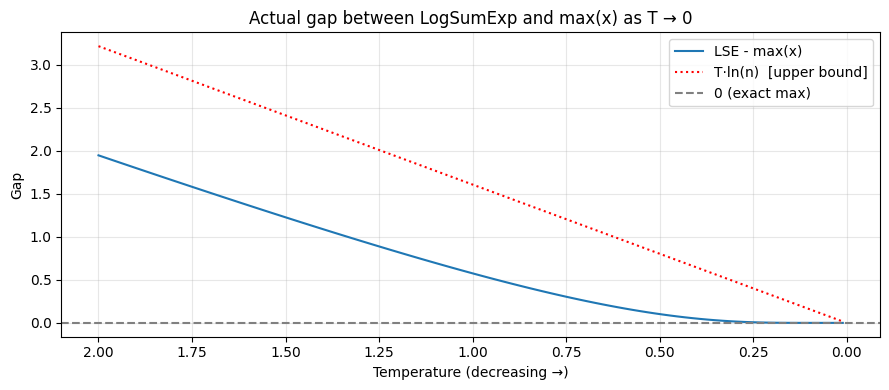

In [23]:
import matplotlib.pyplot as plt

x = np.array([-1.0, 0.5, 2.0, -0.3, 1.1])
temps = np.linspace(2.0, 0.01, 100)

lse_vals    = np.array([act.LogSumExp(x, temp=T) for T in temps])
actual_gap  = lse_vals - np.max(x)
upper_bound = temps * np.log(len(x))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(temps, actual_gap, label="LSE - max(x)")
ax.plot(temps, upper_bound, color="red", linestyle=":", label="T·ln(n)  [upper bound]")
ax.axhline(0, color="gray", linestyle="--", label="0 (exact max)")

ax.invert_xaxis()
ax.set_xlabel("Temperature (decreasing →)")
ax.set_ylabel("Gap")
ax.set_title("Actual gap between LogSumExp and max(x) as T → 0")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

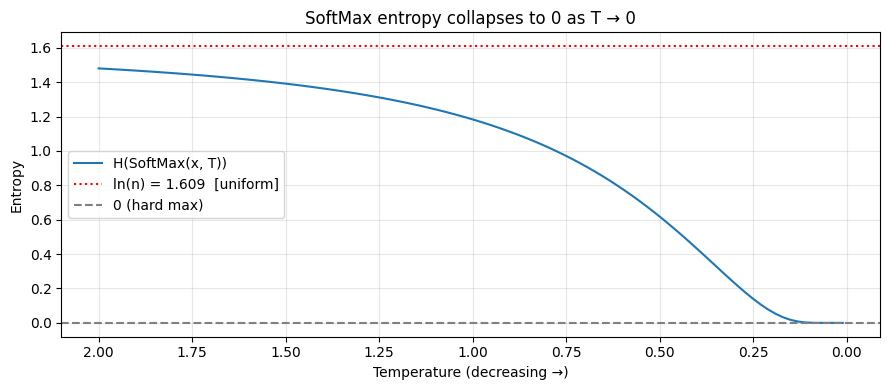

In [24]:
x = np.array([-1.0, 0.5, 2.0, -0.3, 1.1])
temps = np.linspace(2.0, 0.01, 100)

def entropy(p):
    p = np.clip(p, 1e-12, None)
    return -np.sum(p * np.log(p))

softmax_entropy = np.array([entropy(act.SoftMax(x, temp=T, axis=0)) for T in temps])
uniform_entropy = np.log(len(x))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(temps, softmax_entropy, label="H(SoftMax(x, T))")
ax.axhline(uniform_entropy, color="red", linestyle=":", label=f"ln(n) = {uniform_entropy:.3f}  [uniform]")
ax.axhline(0, color="gray", linestyle="--", label="0 (hard max)")

ax.invert_xaxis()
ax.set_xlabel("Temperature (decreasing →)")
ax.set_ylabel("Entropy")
ax.set_title("SoftMax entropy collapses to 0 as T → 0")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()